# Surface Heat Flux

In [1]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from plotting_functions import *

# technical packages
import warnings

## Load Surface Diagnostics & Output

In [13]:
model_run = "MIZ007"
delta_t = 4 # time step in seconsurfDiag
output_dir = "../../MITgcm/so_plumes/" + model_run

# surpress the xmitgcm warning about future changes with timedelta
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    # diagnostic dataset
    surfDiag = open_mdsdataset(output_dir, prefix = ['surfDiag'], delta_t = delta_t, geometry = "cartesian")

    # output dataset
    ds = open_mdsdataset(output_dir, prefix = ['Eta', 'U', 'W', 'T', 'V', 'S', 'PH'], delta_t = delta_t, geometry = "cartesian")

## Heat Fluxes

- TFLUX: "total heat flux (match heat-content variations), >0 increases theta" -> this corresponds to the actual change in temperature
- surForcT: "model surface forcing for Temperature, >0 increases theta" -> what we set as forcing
- oceQnet: "net surface heat flux into the ocean (+=down), >0 increases theta" -> looks like oceQnet = surfForcT in our setting

Difference between surForcT and TFLUX corresponds to heat loss that would drive into ice formation.






## Lead

### Surface Animation

In [77]:
surfDiag

<xarray.Dataset> Size: 7MB
Dimensions:   (XC: 50, YC: 100, XG: 50, YG: 100, Z: 50, Zp1: 51, Zu: 50,
               Zl: 50, time: 13)
Coordinates: (12/37)
  * XC        (XC) >f4 200B 2.0 6.0 10.0 14.0 18.0 ... 186.0 190.0 194.0 198.0
  * YC        (YC) >f4 400B 2.0 6.0 10.0 14.0 18.0 ... 386.0 390.0 394.0 398.0
  * XG        (XG) >f4 200B 0.0 4.0 8.0 12.0 16.0 ... 184.0 188.0 192.0 196.0
  * YG        (YG) >f4 400B 0.0 4.0 8.0 12.0 16.0 ... 384.0 388.0 392.0 396.0
  * Z         (Z) >f4 200B -0.5 -1.55 -2.7 -3.9 ... -166.9 -175.9 -185.1 -194.9
  * Zp1       (Zp1) >f4 204B 0.0 -1.0 -2.1 -3.3 ... -171.3 -180.4 -189.9 -199.9
    ...        ...
    rhoRef    (Z) >f4 200B dask.array<chunksize=(50,), meta=np.ndarray>
    dyF       (YC, XC) >f4 20kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    dyU       (YG, XG) >f4 20kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    maskInW   (YC, XG) bool 5kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    dxF       (YC, XC) >f4 20kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    iter      (time) int64 104B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    ETAN      (time, YC, XC) float64 520kB dask.array<chunksize=(1, 100, 50), meta=np.ndarray>
    TFLUX     (time, YC, XC) float64 520kB dask.array<chunksize=(1, 100, 50), meta=np.ndarray>
    oceQnet   (time, YC, XC) float64 520kB dask.array<chunksize=(1, 100, 50), meta=np.ndarray>
    surForcT  (time, YC, XC) float64 520kB dask.array<chunksize=(1, 100, 50), meta=np.ndarray>
    SFLUX     (time, YC, XC) float64 520kB dask.array<chunksize=(1, 100, 50), meta=np.ndarray>
    oceTAUX   (time, YC, XG) float64 520kB dask.array<chunksize=(1, 100, 50), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='../../MITgcm/...

In [13]:
# TFLUX
animation = True
if animation:
    fig = surface_animation(surfDiag, var='TFLUX', model_run=model_run, time_dim='time', x_dim='XC', y_dim='YC', colorscale="thermal")
    filename = "surface_animation_" + model_run + "_TFLUX" + ".html"
    fig.write_html(filename)
    # fig.show(renderer="browser") # this works in VScode, but not in Jupyterhub

#### Surface Snapshot Lead

In [4]:
surfDiag.XC

<xarray.DataArray 'XC' (XC: 594)> Size: 2kB
array([2.000e+00, 6.000e+00, 1.000e+01, ..., 2.366e+03, 2.370e+03, 2.374e+03],
      shape=(594,), dtype='>f4')
Coordinates:
  * XC       (XC) >f4 2kB 2.0 6.0 10.0 14.0 ... 2.366e+03 2.37e+03 2.374e+03
Attributes:
    standard_name:  plane_x_coordinate
    long_name:      x coordinate
    units:          m
    coordinate:     YC XC
    axis:           X

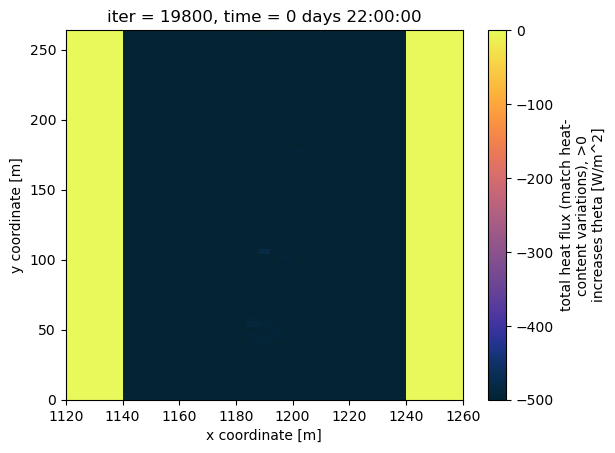

In [12]:
t = 10 #surfDiag.time[10]#
xmin = 280 # needs to be a multiple of 4 +2
xmax = 315 # needs to be a multiple of 4 +2
surfDiag.TFLUX.isel(time=t, XC=slice(xmin, xmax)).plot(x="XC", y="YC", cmap=cmo.thermal)

### Line Plot

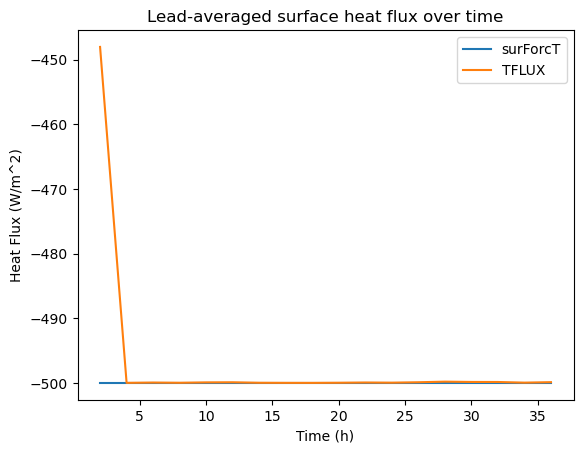

In [49]:
# lead-spatially averaged TFLUX over time
surfDiag_lead = surfDiag.isel(XC=slice(285, 310)) # or .sel with slice(1142, 1238)
surfDiag_lead_mean = surfDiag_lead.mean(dim = ["XC", "YC"])

# plt.plot(surfDiag_lead_mean.time/(60*60*1e9), surfDiag_lead_mean.oceQnet, label = "oceQnet")
plt.plot(surfDiag_lead_mean.time/(60*60*1e9), surfDiag_lead_mean.surForcT, label = "surForcT")
plt.plot(surfDiag_lead_mean.time/(60*60*1e9), surfDiag_lead_mean.TFLUX, label = "TFLUX")


# plt.ylim(-510, -400)

plt.ylabel("Heat Flux (W/m^2)")
plt.xlabel("Time (h)")
plt.title("Lead-averaged surface heat flux over time")
plt.legend()

### Lead Surface Mean Temperature

Text(0.5, 1.0, 'Lead-averaged surface temperature')

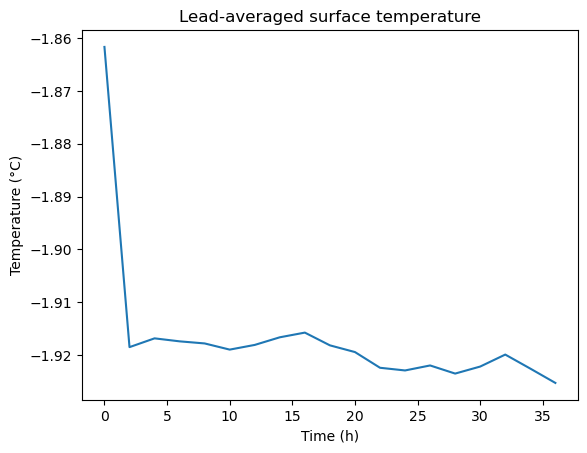

In [42]:
T_lead_surf = ds.T.isel(XC=slice(285, 310), Z=0)
T_lead_surf_mean = T_lead_surf.mean(dim = ["XC", "YC"])

plt.plot(T_lead_surf_mean.time/(60*60*1e9), T_lead_surf_mean)

plt.ylabel("Temperature (°C)")
plt.xlabel("Time (h)")
plt.title("Lead-averaged surface temperature")


## MIZ

In [4]:
# TFLUX
animation = True
if animation:
    fig = surface_animation(surfDiag, var='TFLUX', model_run=model_run, time_dim='time', x_dim='XC', y_dim='YC', colorscale="thermal")
    filename = "surface_animation_" + model_run + "_TFLUX" + ".html"
    fig.write_html(filename)
    # fig.show(renderer="browser") # this works in VScode, but not in Jupyterhub

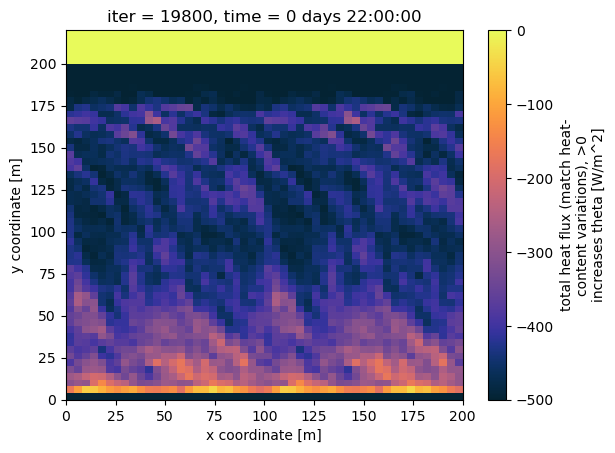

In [48]:
t = 10
ymin = 0
ymax = 55

surfDiag.TFLUX.isel(time=t, YC=slice(ymin, ymax)).plot(x="XC", y="YC", cmap=cmo.thermal)

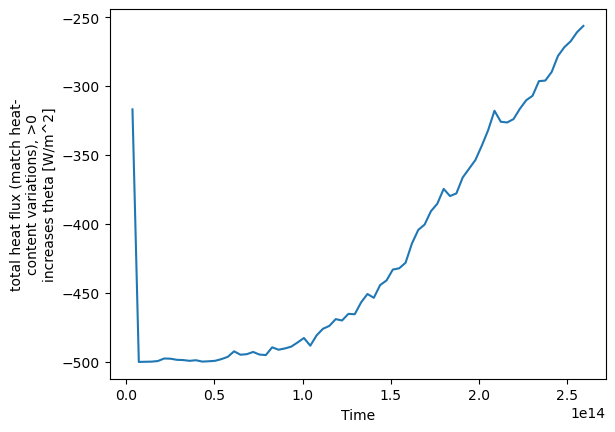

In [12]:
surfDiag.TFLUX.isel(YC = slice(0,50)).mean(dim = ["XC","YC"]).plot()

## Freezing MIZ

When the surface temperature hits the freezing poinit, all remaining heat loss causes ice formation. We get this excess heat loss from the difference between `surForcT` and `TFLUX`

$$ Q_{ice} = \texttt{surfForcT} - \texttt{TFLUX}$$

The thickness of the sea ice produced is then

$$ \Delta h_{ice} = - \frac{1}{\rho_{ice} L}{Q_{ice} \Delta t } $$

The resulting salinity flux due to brine rejections is

$$F_S = -\sigma  \rho_{ice}  \frac{\Delta h_{ice}}{\Delta t} = \frac{\sigma}{L} Q_{ice} $$


 

In [17]:
# ice flux available for ice formation
surfDiag["Q_ice"] = surfDiag["surForcT"] - surfDiag["TFLUX"]
surfDiag.Q_ice.attrs["standard_name"] = "Q_ice"
surfDiag.Q_ice.attrs["long_name"] = "heat flux driving ice formation/melt"

# ice formed/melted in each timestep (assuming equal timesteps)
L = 2.5e5
rho_ice = 900
delta_t = np.float64(surfDiag.time.values[1]-surfDiag.time.values[0])/(1e9) # timestep in s
surfDiag["delta_h_ice"] = - surfDiag.Q_ice*delta_t / (rho_ice*L)
surfDiag.delta_h_ice.attrs["units"] = "m"
surfDiag.delta_h_ice.attrs["standard_name"] = "delta_h_ice"
surfDiag.delta_h_ice.attrs["long_name"] = "Sea ice formed/melted in the timestep"

# salinity flux due to brine rejection
sigma = 30
surfDiag["F_s"] = surfDiag["Q_ice"] * sigma / L
surfDiag.F_s.attrs["units"] = "g/m^2s"
surfDiag.F_s.attrs["standard_name"] = "F_s"
surfDiag.F_s.attrs["long_name"] = "salinity flux due to brine release"

F_s_mean = surfDiag.F_s.isel(YC = slice(0, 50), time = slice(0,48)).values.mean()
print(f"Mean salinity flux due to brine rejection: {F_s_mean:.3f} g/m^2s")

Mean salinity flux due to brine rejection: -0.010 g/m^2s


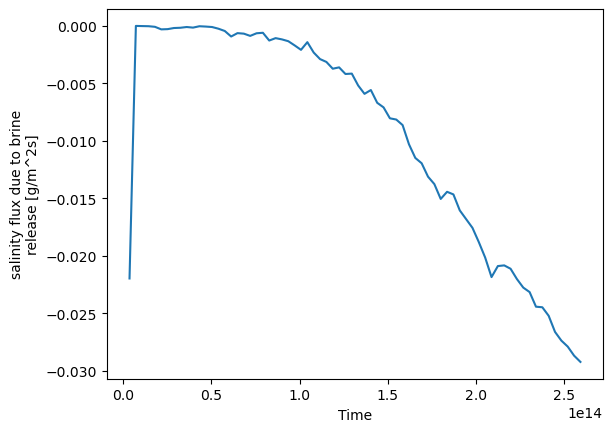

In [10]:
surfDiag.F_s.isel(YC = slice(0, 50)).mean(dim = ["XC","YC"]).plot()

np.float64(0.09047162664653866)

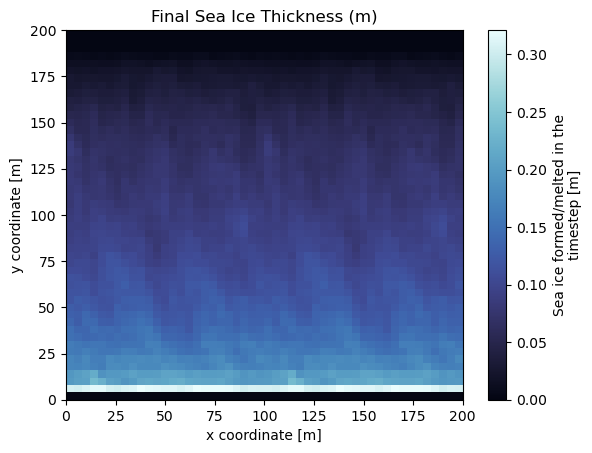

In [11]:
# plot final sea ice
surfDiag.delta_h_ice.isel(YC = slice(0,50)).sum(dim = "time").plot(x="XC", y="YC", cmap=cmo.ice)
plt.title("Final Sea Ice Thickness (m)")

np.mean(surfDiag.delta_h_ice.isel(YC = slice(0,50)).sum(dim = "time").values)